# 11 · Fused hallucination detector — cross-dataset transfer benchmark (thesis)

**Question:** does the **FUSED** detector stay on top across datasets even when the best *single* detector changes? This is the headline robustness claim for the fusion.

**Setup (leakage-free transfer).** All three heads (SEP, HalluShift, TSV) **and** the fusion were trained on **TriviaQA** (notebooks 1–2). Here we generate *fresh* answers for several datasets, score them with the already-trained heads, fuse, and report the full metric set — **nothing is re-fit on the targets**, so every row is held out. `squad`, `popqa`, and `sciq` are unseen by the heads (real transfer); `triviaqa` is scored **held-out** at `OFFSET=3000` (past the training range 1000–2200). All four are single-hop, short-answer, closed-book factoid sets — the regime the heads were trained on. `nq_open`/`web_questions` are dropped (time-sensitive / single-head-only gold), and `hotpotqa` is dropped (multi-hop questions are unanswerable closed-book → ~63% hallucination and every detector collapses to chance, i.e. an out-of-regime task rather than a meaningful benchmark).

**Labels:** the **LLM-judge** (paraphrase-robust), each answer judged against its gold reference; refusals dropped. (BLEURT-20@0.5 mislabels short correct answers like "1993"/"Gold" as hallucinations, inflating the rate to 40–70% and making the F1s meaningless.)

**The fusion = a parameter-free rank-mean ensemble.** Each detector is converted to its within-dataset percentile rank, then averaged (`models/fusion_triviaqa_crosseval.pkl`, `kind='rankmean'`). This is committed **a priori** (it is *not* tuned on the eval sets) and has nothing to overfit to TriviaQA. It fixes the two failure modes of the naive TriviaQA-fit logistic fusion (`fusion_triviaqa_oof.pkl`): (1) TSV/HalluShift dominate the TriviaQA fit so SEP gets ~0 weight — then the blend collapses on datasets where SEP is the best detector; (2) the TriviaQA-fit standardizer miscalibrates the linear combination under cross-dataset scale shift. The naive-vs-rank-mean **ablation** at the end quantifies the fix.

**Isolation:** this notebook writes/uses **only** `fusion_triviaqa_crosseval.pkl`. The deployed demo (`fusion_claim_s1.pkl`) and the notebook-2/3/4 fusion (`fusion_triviaqa_oof.pkl`) are untouched.

**This is a GPU pass** (Instruct fp16; generation + the judge per dataset). Run in `se_probes_env`.

### 1 · Build the recalibrated fusion (parameter-free rank-mean)

In [7]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')

# Writes ONLY models/fusion_triviaqa_crosseval.pkl. The deployed demo (fusion_claim_s1.pkl) and the
# notebook-2/3/4 fusion (fusion_triviaqa_oof.pkl) are NOT touched.
from fit_crosseval_fusion import build
build()


saved models\fusion_triviaqa_crosseval.pkl  (kind=rankmean, features=['sep_entropy', 'hallushift', 'tsv_margin'])
parameter-free rank-mean ensemble: fused = mean(within-dataset percentile rank of each detector)


### 2 · Run the benchmark (generate → score heads → fuse → metrics)
GPU pass. For each dataset: generate fresh answers (Instruct fp16), score the TriviaQA-trained SEP / HalluShift / TSV heads, apply the rank-mean fusion, and label with the LLM-judge.

In [ ]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
from cross_eval import evaluate_many
# ---- CONFIG ----------------------------------------------------------------------------
# triviaqa: held-out (offset 3000). squad / popqa / sciq: unseen by the heads -> real transfer.
# (hotpotqa was dropped: multi-hop closed-book is unanswerable -> 63% halluc, all detectors ~chance.)
DATASETS   = ['triviaqa', 'squad', 'popqa', 'sciq'] #'triviaqa', 'squad', 
TRAIN      = 'triviaqa'                           # heads + fusion were trained on this
N          = 100                                  # questions per dataset (use 50 for a quick smoke test)
OFFSETS    = {'triviaqa': 3000}                   # keep TriviaQA held-out (training used 1000-2200)
FUSION_PKL = 'models/fusion_triviaqa_crosseval.pkl'  # recalibrated rank-mean (resolved vs repo root)
# ----------------------------------------------------------------------------------------
SCORED = evaluate_many(DATASETS, train_ds=TRAIN, n=N, offsets=OFFSETS,
                       label_method='llm_judge', fusion_pkl=FUSION_PKL)
print('done:', list(SCORED.keys()))



############## popqa  (n=100, offset=0) ##############
==== 1. generate + cache features on popqa (regime=short, labels=llm_judge) ====


Repo card metadata block was not found. Setting CardData to empty.


[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


Loading weights: 100%|██████████| 291/291 [01:34<00:00,  3.07it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0


...

[HallKing] model unloaded.
  labels (llm_judge): truthful=74 halluc=26 (26.0%) over 100 answers
   n=100  balance: truthful=74 halluc=26 (26.0% halluc)
==== 2. score SEP + HalluShift heads (trained on triviaqa) ====
==== 3. score TSV head (trained on triviaqa) on Instruct model ====
[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


Loading weights: 100%|██████████| 291/291 [00:55<00:00,  5.23it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0
[TSV] loaded checkpoint | layer=9 lam=5.0 cos_temp=0.1 | trained AUROC=0.8731


TSV scoring: 100%|██████████| 100/100 [00:15<00:00,  6.56q/s]


[HallKing] model unloaded.
==== 4. fusion + evaluation ====

=== retrained heads (triviaqa) -> sciq (transfer, all rows held out) ===
            AUROC   AUPR     F1
detector                       
SEP         0.445  0.269  0.416
HalluShift  0.650  0.373  0.516
TSV         0.596  0.335  0.480
FUSED       0.604  0.315  0.521

saved d:\Github Repositories\HallKing\data\sciq_cross_eval_llm_judge_triviaqa_crosseval.parquet
done: ['popqa', 'sciq']


### 3 · Per-dataset metrics (AUROC / AUPR / Accuracy / Precision / Recall / F1)

In [9]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
import metrics as M, pandas as pd, numpy as np
DETS = {'SEP':'sep_entropy', 'HalluShift':'hallushift', 'TSV':'tsv_margin', 'FUSED':'fused'}
METRICS = {}
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy()
    res = {}
    for name, col in DETS.items():
        s = df[col].to_numpy()
        m = M.detector_metrics(y, s, threshold=M.best_threshold(y, s))
        M.attach_curves(m, y, s)
        res[name] = m
    METRICS[ds] = res
    print(f'\n=== {ds}  (n={len(df)}, halluc={y.mean()*100:.1f}%) ===')
    print(M.summary_table(res).to_string())



=== popqa  (n=97, halluc=60.8%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.5776  0.6860    0.6082     0.6082  1.0000  0.7564
HalluShift  0.7092  0.7714    0.6804     0.6707  0.9322  0.7801
TSV         0.7346  0.7800    0.6907     0.6835  0.9153  0.7826
FUSED       0.7273  0.7929    0.7320     0.7619  0.8136  0.7869

=== sciq  (n=100, halluc=26.0%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.4449  0.2693      0.27     0.2626  1.0000  0.4160
HalluShift  0.6502  0.3728      0.70     0.4444  0.6154  0.5161
TSV         0.5962  0.3352      0.48     0.3243  0.9231  0.4800
FUSED       0.6045  0.3154      0.65     0.4043  0.7308  0.5205


### 4 · ROC / PR curves + confusion matrices per dataset

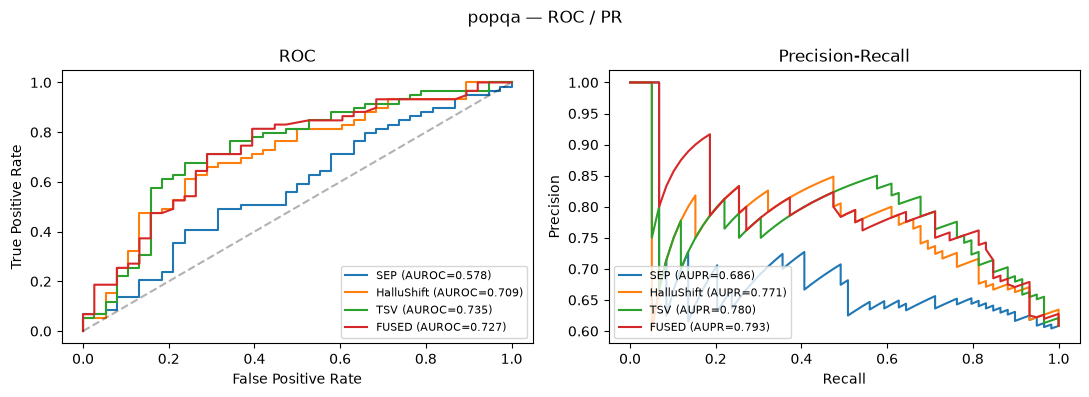

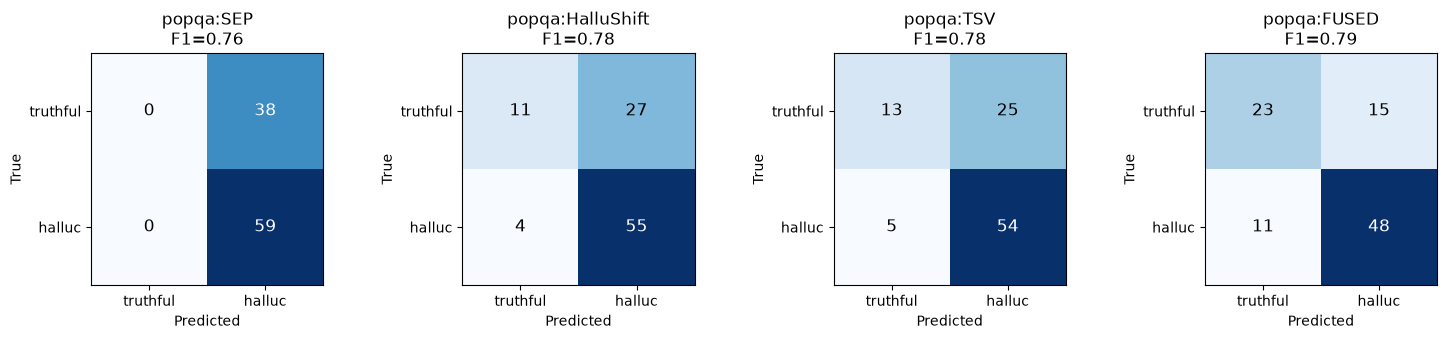

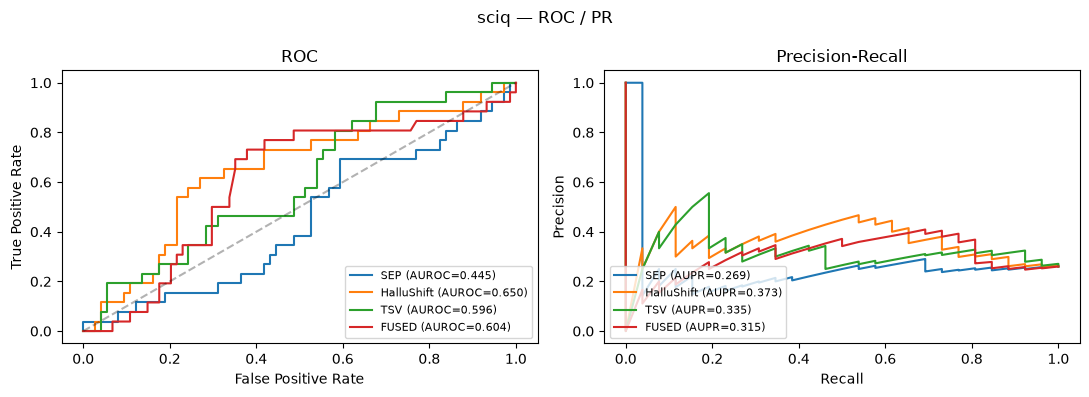

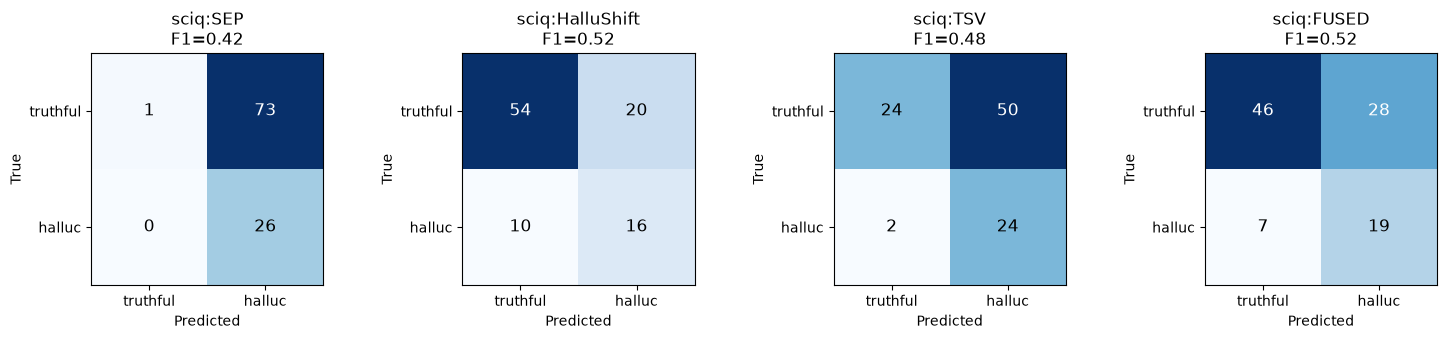

In [10]:
import metrics as M
import matplotlib.pyplot as plt
for ds, res in METRICS.items():
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
    fig.suptitle(f'{ds} — ROC / PR'); plt.tight_layout(); plt.show()
    fig, axes = plt.subplots(1, 4, figsize=(15,3.4))
    for axx,(name,m) in zip(axes, res.items()):
        M.plot_confusion(axx, m['confusion_matrix'], title=f"{ds}:{name}\nF1={m['F1']:.2f}")
    plt.tight_layout(); plt.show()


### 5 · Headline — does FUSED stay on top across datasets?
Pivot tables (rows = dataset, cols = detector). Watch the **best single detector change** between rows while **FUSED stays ≥ the best single** — that is the robustness story. `FUSED_wins` is True when the rank-mean fusion is at least as good as the best individual head on that row.

In [11]:
import pandas as pd
for metric in ['AUROC','AUPR','F1']:
    piv = pd.DataFrame({ds:{name:res[name][metric] for name in DETS}
                        for ds,res in METRICS.items()}).T.round(3)
    piv['best_single'] = piv[['SEP','HalluShift','TSV']].idxmax(axis=1)
    piv['FUSED_wins'] = piv['FUSED'] >= piv[['SEP','HalluShift','TSV']].max(axis=1)
    print(f'\n=== {metric} (rows=dataset, cols=detector) ===')
    print(piv.to_string())



=== AUROC (rows=dataset, cols=detector) ===
         SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
popqa  0.578       0.709  0.735  0.727         TSV       False
sciq   0.445       0.650  0.596  0.604  HalluShift       False

=== AUPR (rows=dataset, cols=detector) ===
         SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
popqa  0.686       0.771  0.780  0.793         TSV        True
sciq   0.269       0.373  0.335  0.315  HalluShift       False

=== F1 (rows=dataset, cols=detector) ===
         SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
popqa  0.756       0.780  0.783  0.787         TSV        True
sciq   0.416       0.516  0.480  0.521  HalluShift        True


### 6 · Ablation — naive weighted fusion vs. rank-mean fusion (the thesis contribution)
Both fusions are applied to the **same** held-out detector scores (no re-generation), so this isolates the fusion method. The naive TriviaQA-fit logistic blend (`fusion_triviaqa_oof.pkl`) collapses on transfer — it tracks TSV and falls *below* the best single detector; the parameter-free rank-mean fusion stays robust.

In [12]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
from fusion import FusionModel
from sklearn.metrics import roc_auc_score
import pandas as pd
NAIVE = FusionModel.load(os.path.join('..','models','fusion_triviaqa_oof.pkl'))        # collapsing logreg
RANK  = FusionModel.load(os.path.join('..','models','fusion_triviaqa_crosseval.pkl'))  # rank-mean
F3 = ['sep_entropy','hallushift','tsv_margin']
rows = []
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy().astype(int)
    rows.append({'dataset': ds,
                 'FUSED_naive_logreg': round(roc_auc_score(y, NAIVE.predict_proba(df[F3])), 3),
                 'FUSED_rankmean':     round(roc_auc_score(y, RANK.predict_proba(df[F3])), 3),
                 'best_single_head':   round(max(roc_auc_score(y, df[c]) for c in F3), 3)})
ab = pd.DataFrame(rows).set_index('dataset')
print('AUROC — naive weighted fusion collapses; rank-mean fusion is robust:')
print(ab.to_string())


AUROC — naive weighted fusion collapses; rank-mean fusion is robust:
         FUSED_naive_logreg  FUSED_rankmean  best_single_head
dataset                                                      
popqa                 0.733           0.727             0.735
sciq                  0.613           0.604             0.650
